## Постановка проблеми

Цей підручник базується на практичному та кодовому підході. Ми визначимо терміни _машинне навчання_ та _лінійна регресія_ в контексті проблеми, а потім узагальнимо їх визначення. Ми пройдемо крок за кроком через типову проблему машинного навчання:


> **ПИТАННЯ**: Компанія ACME Insurance Inc. пропонує доступне медичне страхування тисячам клієнтів по всіх Сполучених Штатах. Як головний дата-сайентіст в ACME, **вам доручено створити автоматизовану систему для оцінки річних медичних витрат для нових клієнтів**, використовуючи інформацію, таку як їх вік, стать, ІМТ, діти, звички щодо куріння та регіон проживання.
>
> Оцінки з вашої системи будуть використовуватися для визначення річної страхової премії (сума, що сплачується щомісяця) пропонованої клієнту. Через регулятивні вимоги, ви повинні мати змогу пояснити, чому ваша система видає певний прогноз.
>
> Вам надано [CSV файл](https://drive.google.com/file/d/13UBFUbkaqccMc4WFHs60tzndCyTOWGE_/view?usp=sharing), що містить перевірені історичні дані, які складаються з вищезгаданої інформації та фактичних медичних витрат, здійснених понад 1300 клієнтами.
> <img src="https://i.imgur.com/87Uw0aG.png" width="480">
>
> Джерело набору даних: https://github.com/stedy/Machine-Learning-with-R-datasets


**ВПРАВА 1**: Перед тим як продовжувати, зупиніться на мить і подумайте, як ви можете підійти до цієї проблеми. Запишіть п'ять або більше ідей, які приходять вам на думку нижче:

1. Проаналізувати кореляцію між параметрами (вік, стать, ІМТ, і тд) (наприклад, за допомогою heatmap) та первинно визначити, які фактори найбільше корелюють з розміром внеску. На основі отриманої інформації відсіяти метрики, які мало впливають на ціну та дослідити, що впливає найбільше
2. Перевірити, є локальні цінові пропозиції по страхуванню чи спеціальні програми для верств населення. Якщо певні конкретні регіони/категорії населення обмежені в пропозиції, для них легше спрогнозувати витрати через брак опцій. Або, навпаки, якщо є багато опцій - дослідити, які обираються найчастіше і цим звузити варіанти вибору цінових пропозицій для більшості випадків.
3. Значення ІМТ та наявність шкідливих звичок може суттєво впливати на кількість страхових випадків, тому найімовірніше, для зони ризику страхові випадки будуть частіші, тож внески потрібно збільшувати.
4. Вік та наявність дітей може збільшувати ймовірність вікових захворювань та страхових випадків. Потрібно проаналізувати також кореляцію цих факторів з вартістю внеску
5. Визначити категорії клієнтів, які з високю ймовірністю не зможуть/зможуть робити великі чи малі внески. Наприклад, молодь, зокрема студенти, часто не мають фінансової стабільності такої, як у старшої молоді.

## Завантаження даних

Для початку, давайте завантажимо дані з файлу csv.

In [1]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'/content/drive/MyDrive/ML Intensive from 0 to Hero/medical-charges.csv'

In [ ]:
!ls 'drive/MyDrive/ML Intensive from 0 to Hero'

In [4]:
file_name = 'medical-charges.csv'

In [5]:
medical_df = pd.read_csv(file_name)

In [6]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Набір даних містить 1338 рядків та 7 стовпців. Кожен рядок набору даних містить інформацію про одного клієнта.

Наша мета - знайти спосіб оцінки значення в стовпці "charges", використовуючи значення в інших стовпцях. Якщо ми можемо це зробити для історичних даних, то ми повинні змогти оцінити вартість для нових клієнтів, просто запитавши інформацію, таку як їх вік, стать, ІМТ, кількість дітей, звички щодо куріння та регіон.

Давайте перевіримо тип даних для кожного стовпця.

In [7]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Схоже, що "вік", "діти", "ІМТ" ([індекс маси тіла](https://en.wikipedia.org/wiki/Body_mass_index)) та "платежі" є числами, тоді як "стать", "курець" та "регіон" є рядками (можливо, категоріями). Жоден з стовпців не містить пропущених значень, що економить нам чимало часу!

Про те, як можна заповнювати пропущені дані і чому це варто робити - розповідаю на великому курсі, а для тих, хто хоче розібратись прямо зараз рекомендую [статтю](https://www.analyticsvidhya.com/blog/2021/10/handling-missing-value/) .

Глянемо статистику для числових стовпців:

In [10]:
medical_df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


Діапазони значень в числових стовпцях також здаються розумними (немає від'ємного віку!), тому нам може не довестися робити багато очищення даних або корекції. Однак стовпець "charges" здається значно спотвореним, оскільки медіана (50 перцентиль) набагато нижча за максимальне значення.

> **ВПРАВА 2**: Які інші висновки ви можете зробити, переглядаючи таблицю вище? Додайте свої висновки нижче:
>
> 1. Дані по віку розполені досить рівномірно (медіна та середнє близькі за значенням), 2 та 3 квартилі рівновіддалені від медіани, отже між квартилями дані по віку розподілені дуже рівномірно. Різниця між max та Q3 невелика в масштабах віку з даних, тому можна очікувати, що викидів у віку немає.
> 2. Аналогічно, ІМТ теж не має значного збільшення в бік великих чи малих значень (медіана та середнє близькі), проте різниця між Q3 та max значна, отже є кілька показників ІМТ, значно вищих за більшість. На це також вказує мала різниця Q3-Q2 порівняно з max - Q3.
> 3. Кількість дітей у 50% клієнтів не більше 1, проте після медіани у половини клієнтів від 1 до 2 дітей, і в 4 квартилі невелика кількість клієнтів має до 5 дітей, проте 5 - це максимальне значення і, ймовірно, більшість значень у 4 квартилі не дуже великі, оскільки середнє близьке до медіани та не скошене в бік великих значень.
> 4. Серед розмірів виплат розподіл не такий рівномірний, оскільки середнє зсунуте в бік більших значень, отже в 3 і 4 квартилі зосереджені досить високі значення (на що також вказує великий std)
> 5. Загалом дані виглядають реалістично, немає від'ємних значень

## Дослідницький аналіз та візуалізація з plotly

Давайте дослідимо дані, візуалізуючи розподіл значень у деяких стовпцях набору даних, а також взаємозв'язки між "витратами" та іншими стовпцями.

В машинному навчанні найчастіше використовують бібліотеки Matplotlib, Seaborn та Plotly для візуалізації. І ми теж будемо працювати з ними. Аби отримати інтро про те, як ними користуватись - рекомендую наступні ресурси Ознайомтеся з цими посібниками, щоб дізнатися, як використовувати ці бібліотеки:

- https://matplotlib.org/stable/users/explain/quick_start.html
- https://plotly.com/python/getting-started/

Але навіть якщо ви ніколи не користувались цими існтрументами - це не біда. Просто робіть за мною за аналогією і ви вже будете будувати найнеобхіжніші графіки. А в роботі можете просто потім скопіювати код звідси 😉

Спочатку імпортуємо всі лібки. Зазвичай ми їх імпортуємо саме в такий спосіб, це зручно для подальшого використання.

In [11]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Наступні налаштування допоможуть покращити стандартний стиль та розміри шрифтів для наших діаграм. Налаштування за замовченням - теж норм. Справа смаку.

In [12]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

### Вік

Вік - це числова колонка. Мінімальний вік в наборі даних - 18 років, а максимальний - 64 роки. Таким чином, ми можемо візуалізувати розподіл віку, використовуючи гістограму з 47 бінами (один на кожен рік) та ящик з вусами. Ми використаємо plotly для створення інтерактивної діаграми, але ви можете створити подібні діаграми, використовуючи Seaborn.

Про те, які бувають графіки і коли який використовувати можна ознайомитись тут:

  https://datavizcatalogue.com/

In [13]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [14]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

Розподіл віку в наборі даних майже рівномірний, з 20-30 клієнтами на кожен вік, за винятком 18 та 19 років, де здається, що клієнтів більше ніж у два рази порівняно з іншими віками. Рівномірний розподіл може виникнути через те, що немає великої варіації в [кількості людей певного віку](https://www.statista.com/statistics/241488/population-of-the-us-by-sex-and-age/) (між 18 та 64 роками) в США.

> **ВПРАВА 3**: Чи можете ви пояснити, чому клієнтів віком 18 та 19 років більше ніж у два рази порівняно з іншими віками?
>
> Можливо, у 18 та 19 років при досягненні повноліття зазвичай купується страхування. Інші вікові категорії можуть поновлювати або змінювати страхування

### Індекс маси тіла

Давайте подивимося на розподіл ІМТ (Індексу маси тіла) клієнтів, використовуючи гістограму та ящик з вусами.

In [15]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

Вимірювання індексу маси тіла, здається, формують [гауссівський розподіл](https://en.wikipedia.org/wiki/Normal_distribution), центрований навколо значення 30, з кількома викидами вправо. Ось як можна інтерпретувати значення ІМТ ([джерело](https://study.com/academy/lesson/what-is-bmi-definition-formula-calculation.html)):

![](https://i.imgur.com/lh23OiY.jpg)

> **ВПРАВА 4**: Чи можете ви пояснити, чому розподіл віків формує рівномірний розподіл, а розподіл ІМТ формує гауссовий розподіл?
>
> ІМТ є випадковою змінною, яка здебільшого не залежить від віку, статі тощо. Навіть якщо вік розподілений рівномірно, ІМТ є випадковим значенням. Для випадкових значень в процесах найчастіше використовують опис нормальним розподілом (проте в житті він не є ідеально симетричним). Щодо рівномірності розподілу віку, розподіл клієнтів є вибіркою, яка відображає дані про розподіл населення в США, який є досить близьким до рівномірного.

### Збори

Давайте візуалізуємо розподіл "зборів", тобто річних медичних витрат для клієнтів. Це колонка, яку ми намагаємося передбачити. Також використовуймо категоріальну колонку "курець", щоб відрізнити збори для курців та некурців.

In [17]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

Ми можемо зробити наступні спостереження з вищенаведеного графіку:

* Для більшості клієнтів річні медичні витрати становлять менше \$10,000. Тільки невелика частина клієнтів має вищі медичні витрати, можливо, через нещасні випадки, серйозні хвороби та генетичні захворювання. Розподіл схожий на експоненційний ("power law").
* Існує значна різниця в медичних витратах між курцями та некурцями. Тоді як медіана для некурців становить \$7300, медіана для курців наближається до \$35,000.


> **ВПРАВА 5**: Візуалізуйте розподіл медичних витрат у зв'язку з іншими факторами, такими як "стать" та "регіон". Що ви спостерігаєте?

In [19]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['grey', 'blue'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

* Медіана виплат для чоловіків та жінок практично співпадає, проте q3 для чоловіків значно більше, ніж для жінок. Окрім того, у виплатах більше $30,000 переважають чоловіки.Можливо, це пов'язано або з більшою схильністю до хвороб та страхових випадків саме для чоловіків.
* Для нижчих медичних витрат ($2,000 - $28,000) співвідношення кількості чоловіків та жінок майже рівні, більша відмінність з'являється для більших витрат.

In [21]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

* Медіани витрат для всіх регіонів близькі ($9,000 - $10,000), проте значна різниця спостергіється у q3. Для регіону southeast найбільше значення для q3, отже більше виплат у сумах $16,000 - $19,000. Тобто можна сказати, що для регіону southeast та northeast розміри виплат можуть бути більшими, проте, відповідно до візуалізації, це не є чіткою закономірністю.
* Розподіл витрат від $14,000 загалом не має явних відмінностей для різних регіонів, викиди містяться у всіх регіонах без різких відмінностей.

### Курець

Давайте візуалізуємо розподіл колонки "курець" (що містить значення "так" та "ні") за допомогою гістограми.

In [22]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

Виглядає, що лише 20% клієнтів повідомили, що вони курять. Маючи якусь нац статистику щодо куріння ми б могли порівняти це з даними.Чи можете ви перевірити, чи відповідає це національному середньому, припускаючи, що дані були зібрані у 2010 році? Ми також бачимо, що куріння здається більш поширеним звичкам серед чоловіків. Чи можете ви це підтвердити?

> **ВПРАВА 6**: Візуалізуйте розподіл стовпців "стать", "регіон" та "діти" та описуйте свої спостереження.

In [29]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color='sex',
                   title='BMI by Sex')
fig.update_layout(bargap=0.1)
fig.show()

Помітно, що розподіл ІМТ для чоловіків та жінок приблизно однаковий, для жінок трохи менший ІМТ загалом, але медіани для чоловіків та жінок юлизькі. Лише максимальні значення ІМТ відповідають даним чоловіків, проте це викиди, їх кількість недостатня для встановлення закономірності. 
Отже, можна зробити висновки:
- ІМТ та стать рівномірно розподілені, 
- ІМТ дані загалом розподілені нерівномірно (що є очікуваним для випадкових величин)
- ІМТ загалом не залежить від статі клієнта

In [34]:
px.histogram(medical_df, x='age', marginal='box', color='region', title='Age by Region')

З розподілу віку за регіонами можна побачити, що у всіх регіонах розподіл клієнтів по віку близький один до одного, тобто немає явно вираженого регіону, де переважає населення молодшого чи старшого віку. Отже, за регіоном неможливо визначити клієнтів, які схильні до вікових хвороб та підпадають під більшу кількість страхових випадків у зв'язку з віком.

In [25]:
px.histogram(medical_df, x='children', color='sex', title='Children')

* За гістограмою розподілу кількості дітей можна побачити, що більшість людей не мають дітей, а ті, хто має, найчастіше мають 1 або 2 дітей. Це може впливати на медичні витрати, оскільки люди з дітьми можуть мати більше медичних потреб.
* Розподіл також показує, що чоловіки та жінки рівномірно представлені відносно кількості дітей. Звідси можна зробити висновок, що: 
    1. чоловіки та жінки майже однаковою мірою оформлюють страхування незалежно від кільксті дітей; 
    2. Можливі випадки, коли страхування оформлюють чоловік та дружина, через що частина клієнтів різної статі може мати однакові дані щодо кількості дітей

Після того, як ми розглянули окремі стовпці, тепер можемо візуалізувати взаємозв'язок між "витратами" (значенням, яке ми хочемо прогнозувати) та іншими стовпцями.

### Вік та витрати

Давайте візуалізуємо взаємозв'язок між "віком" та "витратами", використовуючи діаграму розсіювання. Кожна точка на діаграмі розсіювання представляє одного клієнта. Ми також використаємо значення у стовпці "курець" для кольору точок.

In [37]:
fig = px.scatter(medical_df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

Ми можемо зробити наступні висновки з вищенаведеної діаграми:

* Загальна тенденція, здається, полягає в тому, що медичні витрати зростають з віком, як ми могли б очікувати. Однак, є значна варіативність на кожному віці, і очевидно, що вік від самого себе не може бути використаний для точного визначення медичних витрат.


* Ми можемо побачити три "кластери" точок, кожен з яких, здається, формує лінію зі зростаючим нахилом:

     1. Перший і найбільший кластер складається, головним чином, з "здорових некурців", які мають відносно низькі медичні витрати порівняно з іншими.
     
     2. Другий кластер містить суміш курців і некурців. Можливо, це насправді два різних, але перекриваються кластери: "некурці з медичними проблемами" та "курці без серйозних медичних проблем".
     
     3. Останній кластер складається виключно з курців, очевидно, курців з серйозними медичними проблемами, які, можливо, пов'язані або погіршені курінням.

     4. Для "здорових некурців" загалом витрати за віком щільно розташовані. Для середнього кластера та кластера курців розкид розмірів витрат в кожному віці зростає, зокрема найбільший розкид в курців. Це означає, що здорові некурці зазвичай мають меншу варіантивність витрат, ніж курці та некурці з можливими захворюваннями. Тобто, на категорію курців припадають найбільші розміри витрат.

### Індекс маси тіла та витрати

Давайте візуалізуємо відношення між ІМТ (індексом маси тіла) та витратами, використовуючи ще один діаграму розсіювання. Ще раз використаємо значення з колонки "курець" для кольору точок.

In [38]:
fig = px.scatter(medical_df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

Здається, що для некурців збільшення ІМТ не здається пов'язаним зі збільшенням медичних витрат. Однак медичні витрати, здається, значно вищі для курців з ІМТ більше 30.

Які інші висновки ви можете зробити з вищенаведеного графіка?

> **ВПРАВА 8**: Створіть ще декілька графіків для візуалізації зв'язку між стовпцем "charges" та іншими стовпцями ("children", "sex", "region" та "smoker"). Підсумуйте висновки, отримані з цих графіків.
>
> *Підказка*: Використовуйте графіки-скрипки (`px.violin`) та стовпчасті діаграми (`sns.barplot`)

In [40]:
fig = px.violin(medical_df,
                y='charges', 
                x = 'smoker',
                color='sex',
                box=True, points='all',
                title='Charges by Smoking Status and Sex')
fig.show()

З отриманої візуалізації видно:
- для курців розміри витрат більші, ніж для некурців для обох статей
- для курців-чоловіків більша густина імовірності вищих витрат, ніж для жінок-курців (kde для курців-чоловіків вище від медіани більша, ніж для жінок-курців)
- для некурців-жінок вища ймовірність більших витрат, ніж для чоловіків-некурців (верхній "хвіст" довший для діаграми жінок-некурців), проте для більшості даних розподіл витрат для некурців незначно залежить від статі
- для некурців більшість даних про вартість витрат розташовані щільно, отже в більшості випадків для клієнтів з категорії некурців витрати будуть схожими

In [41]:
fig = px.violin(medical_df,
                y='charges', 
                x = 'children',
                color='sex',
                box=True, points='all',
                title='Charges by Number of Children and Sex')
fig.show()

- Щільне розташування точок для 0-2 дітей вказує на те, що переважна більшість клієнтів має від 0 до 2 дітей, меншість - 3 і більше
- Густина ймовірності вказування кількості дітей більша для жінок загалом
- Розміри витрат для клієнтів з 1-3 дітьми майже не відрізняються (мають близькі медіани та щільності розподілу), для клієнтів без дітей зустрічається більше високих виплат

Text(0, 0.5, 'Average Charges')

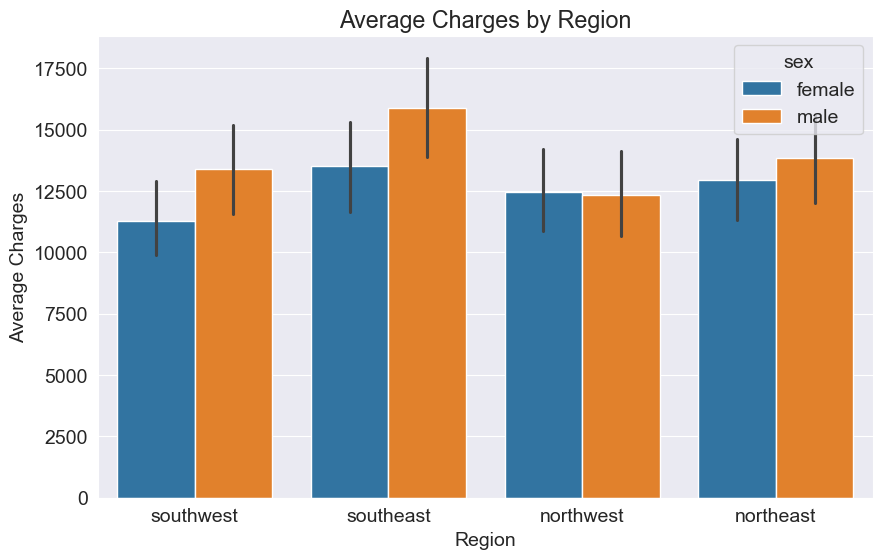

In [44]:
import seaborn as sns
fig = sns.barplot(medical_df, x='region', y='charges', hue='sex')
fig.set_title('Average Charges by Region')
fig.set_xlabel('Region')
fig.set_ylabel('Average Charges')

- Для чоловіків у всіх регіонах, окрім northwest, розміри витрат більші, ніж для жінок
- За регіоном та статтю, найбільші витрати для чоловіків у регіоні southeast

### Кореляція

Як ви можете бачити з аналізу, значення в деяких стовпцях більш тісно пов'язані зі значеннями в "charges" порівняно з іншими стовпцями. Наприклад, "age" та "charges" здається ростуть разом, тоді як "bmi" та "charges" - ні.

Цей зв'язок часто виражається числово за допомогою міри, яка називається _коефіцієнтом кореляції_, який можна обчислити за допомогою методу `.corr` серії Pandas.

In [45]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [46]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362884)

Щоб обчислити кореляцію для категоріальних стовпців, їх спочатку потрібно перетворити на числові стовпці.

In [47]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984767)

Ось як можна інтерпретувати коефіцієнти кореляції ([джерело](https://statisticsbyjim.com/basics/correlations)):

* **Сила**: Чим більше абсолютне значення коефіцієнта кореляції, тим сильніше відношення.

    * Крайні значення -1 та 1 вказують на ідеально лінійне відношення, коли зміна однієї змінної супроводжується абсолютно стабільною зміною іншої. Для цих відношень усі точки даних розташовані на лінії. На практиці ви не побачите жодного типу ідеального відношення.

    * Коефіцієнт нуля представляє відсутність лінійного відношення. Коли одна змінна збільшується, інша змінна не має тенденції збільшуватися або зменшуватися.
    
    * Коли значення знаходиться між 0 та +1/-1, існує відношення, але точки не всі розташовані на лінії. Як r наближається до -1 або 1, сила відношення збільшується, і точки даних схильні розташовуватися ближче до лінії.


* **Напрямок**: Знак коефіцієнта кореляції представляє напрямок відношення.

    * Позитивні коефіцієнти вказують на те, що коли значення однієї змінної збільшується, значення іншої змінної також має тенденцію збільшуватися. Позитивні відношення створюють підйомний нахил на діаграмі розсіювання.
    
    * Негативні коефіцієнти представляють випадки, коли при збільшенні значення однієї змінної, значення іншої змінної має тенденцію зменшуватися. Негативні відношення створюють спадний нахил.

Ось таке ж відношення, виражене візуально ([джерело](https://www.cuemath.com/data/how-to-calculate-correlation-coefficient/)):

<img src="https://i.imgur.com/3XUpDlw.png" width="360">

Коефіцієнт кореляції має наступну формулу:

<img src="https://i.imgur.com/unapugP.png" width="360">

Ви можете дізнатися більше про математичне визначення та геометричну інтерпретацію кореляції тут: https://www.youtube.com/watch?v=xZ_z8KWkhXE

Pandas dataframes також надає метод `.corr` для обчислення коефіцієнтів кореляції між усіма парами числових стовпців.

In [48]:
?medical_df.corr

Signature:
medical_df.corr(
    method: 'CorrelationMethod' = 'pearson',
    min_periods: 'int' = 1,
    numeric_only: 'bool' = False,
) -> 'DataFrame'
Docstring:
Compute pairwise correlation of columns, excluding NA/null values.

Parameters
----------
method : {'pearson', 'kendall', 'spearman'} or callable
    Method of correlation:

    * pearson : standard correlation coefficient
    * kendall : Kendall Tau correlation coefficient
    * spearman : Spearman rank correlation
    * callable: callable with input two 1d ndarrays
        and returning a float. Note that the returned matrix from corr
        will have 1 along the diagonals and will be symmetric
        regardless of the callable's behavior.
min_periods : int, optional
    Minimum number of observations required per pair of columns
    to have a valid result. Currently only available for Pearson
    and Spearman correlation.
numeric_only : bool, default False
    Include only `float`, `int` or `boolean` data.

    .. versio

In [49]:
medical_df.corr(numeric_only=True).round(3)

,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


Результат `.corr` називається матрицею кореляції і часто візуалізується за допомогою теплової карти.

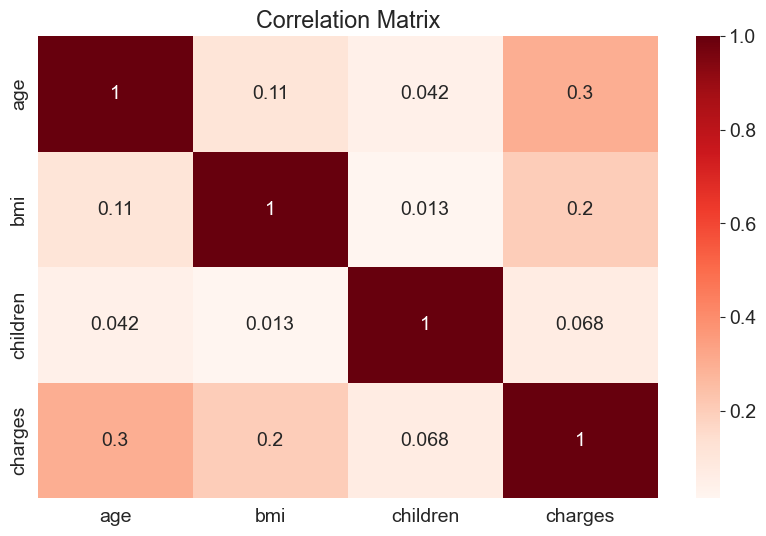

In [50]:
sns.heatmap(medical_df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix');

**Correlation vs Causality:** Зверніть увагу, що висока кореляція не може бути використана для інтерпретації причинно-наслідкового зв'язку між характеристиками. Дві характеристики $X$ та $Y$ можуть бути корельовані, якщо $X$ спричиняє $Y$ або якщо $Y$ спричиняє $X$, або якщо обидва незалежно спричинені якимось іншим фактором $Z$, і кореляція більше не буде вірною, якщо один з причинно-наслідкових зв'язків порушено. Також можливо, що $X$ та $Y$ просто здаються корельованими, тому що вибірка занадто мала.

Хоча це може здатися очевидним, комп'ютери не можуть відрізнити кореляцію від причинності, і рішення, прийняті на основі автоматизованої системи, часто можуть мати великі наслідки для суспільства, тому важливо вивчати, чому автоматизовані системи призводять до певного результату. Визначення причинно-наслідкових зв'язків вимагає людського розуміння.